In [1]:
#%load_ext autoreload
#%autoreload 2

import os
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

## Автоматический подбор элементов дизайна на основе визуального представления

In [2]:
from tqdm import tqdm
from PIL import Image
import torch
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from matplotlib.gridspec import GridSpec
#
from img2vec_pytorch import Img2Vec
#
import ultralytics
from ultralytics import YOLO
#
from ultralytics.cfg import get_cfg

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [4]:
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.is_available()}')
    print(f'CUDA version: {torch.version.cuda}')
    print(f'count: {torch.cuda.device_count()}')
    print(f'index: {torch.cuda.current_device()}')
    print(f'name: {torch.cuda.get_device_name(0)}')
else:
    print('Nvidia GPU отсутствует или PyTorch не установлен для CUDA')

GPU: True
CUDA version: 12.6
count: 1
index: 0
name: NVIDIA GeForce RTX 4060


In [5]:
current_dir = os.getcwd()
data_dir = os.path.join(current_dir, 'data', 'ImageSearch')
print(data_dir)
print()
print('В ней находятся:')
print(os.listdir(data_dir))

E:\Progi\PythonProg\OtusML\Professional\Homework\OtusMLprof25\project_work\data\ImageSearch

В ней находятся:
['dataset', 'user_img']


## 1. Раcпознаём объекты на входном изображении

In [6]:
# Подготавливаем путь к входному изображению
input_img_path_name = os.path.join('user_img', 'living_room.jpg')
print(input_img_path_name)
input_img_path = os.path.join(data_dir, input_img_path_name)
print(input_img_path)

user_img\living_room.jpg
E:\Progi\PythonProg\OtusML\Professional\Homework\OtusMLprof25\project_work\data\ImageSearch\user_img\living_room.jpg


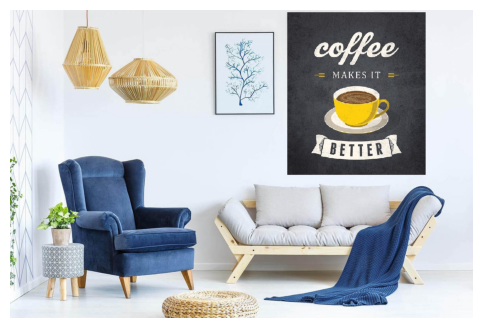

In [7]:
input_img = Image.open(input_img_path).convert('RGB')

fig = plt.figure(figsize=(6, 4), dpi=100)
plt.imshow(input_img)
plt.axis('off')
plt.show()

In [8]:
# Подготавливаем модель
# model = YOLO('yolo11l.pt')
# model = YOLO('yolov10l.pt')
# model = YOLO('yolov9c.pt')
model = YOLO('yolov8l.pt')

# Доступные модели и их отличия:
# https://docs.ultralytics.com/models

In [9]:
# Смотрим на доступные аргументы
#config = get_cfg()  
#print(config)

# Детальная информация по аргументам:
# https://github.com/ultralytics/ultralytics/blob/main/ultralytics/cfg/default.yaml
# https://docs.ultralytics.com/modes/predict/#inference-arguments

In [10]:
yolo_result_path = 'YOLO_image_results'

In [11]:
# Запускаем распознавание
results = model.predict(
    source=input_img_path,
    # Сохранять одно изображение со всеми распознанными объектами
    save=True,
    # Сохранять координаты всех распознанных объектов
    save_txt=True,
    # Сохранять распознанные объекты в отдельных файлах
    save_crop=True,
    # Список классов, которые нужно распознать
    classes=[41, 56, 57],  # cup, chair, couch
    # Коэффициент уверенности распознавания
    conf=0.5,
    #device='cpu',  # 'cpu или индекс для GPU, например 0
    device=0,
    # Директория, куда созранять результаты распознавания
    project=yolo_result_path
)


image 1/1 E:\Progi\PythonProg\OtusML\Professional\Homework\OtusMLprof25\project_work\data\ImageSearch\user_img\living_room.jpg: 448x640 1 cup, 1 chair, 1 couch, 31.9ms
Speed: 2.8ms preprocess, 31.9ms inference, 267.7ms postprocess per image at shape (1, 3, 448, 640)
Results saved to YOLO_image_results\predict
1 label saved to YOLO_image_results\predict\labels


In [12]:
# Извлекаем путь к директориии с текущим результатом распознавания
save_dir = results[0].save_dir
#
print(save_dir)

YOLO_image_results\predict


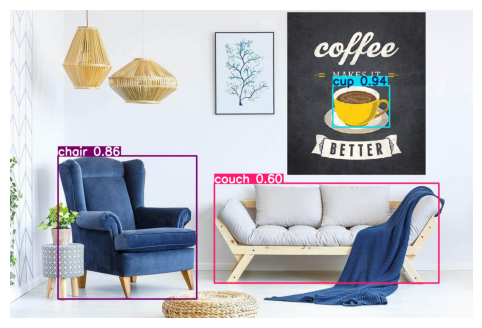

In [13]:
# Подготавливаем путь к распознанному изображению
input_img_deteсted_path = os.path.join(save_dir, 'living_room.jpg')
# Показываем изображение с распознанными объектами
#ImageDisplay(input_img_deteсted_path, width=700)

input_img_deteсted = Image.open(input_img_deteсted_path).convert('RGB')

fig = plt.figure(figsize=(6, 4), dpi=100)
plt.imshow(input_img_deteсted)
plt.axis('off')
plt.show()

In [14]:
# Подготавливаем путь к директории с вырезанными объектами
crops_path = os.path.join(save_dir, 'crops')

# Подготавливаем список с путями ко всем вырезанным объектам
crops_paths_lst = []
crops_filenames_lst = []

# Собираем имена всех файлов вырезанных объектов и помещаем их в список
for root, dirs, files in os.walk(crops_path):
    for file in files:
        crops_paths_lst.append(os.path.join(root, file))
        crops_filenames_lst.append('_in_'.join([root.split(os.sep)[-1], file]))

print(crops_paths_lst)
print()
print(crops_filenames_lst)

['YOLO_image_results\\predict\\crops\\chair\\living_room.jpg', 'YOLO_image_results\\predict\\crops\\couch\\living_room.jpg', 'YOLO_image_results\\predict\\crops\\cup\\living_room.jpg']

['chair_in_living_room.jpg', 'couch_in_living_room.jpg', 'cup_in_living_room.jpg']
